# 🏛️ 03 · 经典 CNN 架构与残差网络

> 目标：把 02 篇的卷积积木拼成真正的网络——从 LeNet 到 ResNet 逐代演化讲清「每个架构解决什么问题」，
> 手撕残差块并做**有无残差连接的深度网络对比实验**，再补深度可分离卷积（MobileNet）与 SE 注意力。

> 🧩 **生活化类比**：网络架构 = 建筑的梁柱结构。LeNet 是小平房，VGG 是等高的砖楼（3x3 砖），
> ResNet 给每层加了一根「电梯直达通道」（skip connection）——信息不掉队，楼才盖得高。


## 1. 架构谱系总表（一页背完）

| 模型 | 年份 | 参数 | 关键思想 | 一句话定位 |
|------|------|------|----------|------------|
| LeNet-5 | 1998 | 60K | 卷积+池化+全连接 | 第一个经典 CNN（手写数字） |
| AlexNet | 2012 | 60M | ReLU / Dropout / 数据增强 / GPU | ImageNet 冠军，深度学习元年 |
| VGG-16 | 2014 | 138M | 3x3 小核堆叠 | 简单规整，可迁移性极强 |
| GoogLeNet | 2014 | 6.8M | Inception 多尺度 + 1x1 降维 | 参数效率革命 |
| ResNet-50 | 2015 | 25.6M | **残差连接** | 解决深度网络退化，152 层可训 |
| DenseNet | 2017 | 8.1M | 特征跨层复用（密集连接） | 梯度传播更短 |
| MobileNet | 2017 | 4.2M | **深度可分离卷积** | 移动端高效 |
| EfficientNet | 2019 | 5.3M | NAS + 复合缩放 | 精度/算力帕累托最优 |

> 主线问题链：**不够快（GPU）→ 不够深（退化）→ 不够轻（移动端）→ 找最优结构（NAS）**。


## 2. LeNet-5：逐层参数量手算

| 层 | 配置 | 输出尺寸 | 参数量 |
|----|------|----------|--------|
| C1 | 6 个 5x5 核，stride1 | 28x28x6 | $6\\times(1\\times25+1)=156$ |
| S2 | 2x2 平均池化 | 14x14x6 | $6\\times(1+1)=12$（可学习系数） |
| C3 | 16 个 5x5 核（部分连接） | 10x10x16 | 约 1516 |
| S4 | 2x2 池化 | 5x5x16 | 32 |
| C5 | 120 个 5x5 核 | 1x1x120 | $120\\times(16\\times25+1)=48120$ |
| F6 | 84 | 84 | $120\\times84+84=10164$ |
| 输出 | 10（RBF/softmax） | 10 | 850 |

**面试点**：LeNet 的池化后有可学习的缩放系数（现代已不用）；C3 用部分连接省参数、打破对称。


In [1]:
# ---------- 实验 1：LeNet 参数量复算 + torch 实现对照 ----------
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def count_params(model):
    return sum(p.numel() for p in model.parameters())

class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x)); x = F.relu(self.fc2(x))
        return self.fc3(x)

net = LeNet()
print('LeNet 总参数量:', count_params(net), '（经典论文约 60K，含部分连接差异）')
x = torch.randn(4, 1, 28, 28)
print('前向输出形状:', tuple(net(x).shape), '（4 张 28x28 -> 4x10 分数）')

# 逐层形状演算
with torch.no_grad():
    a = F.max_pool2d(F.relu(net.conv1(x)), 2)
    print('conv1+pool:', tuple(a.shape))
    b = F.max_pool2d(F.relu(net.conv2(a)), 2)
    print('conv2+pool:', tuple(b.shape), '展平后 =', b.shape[1] * b.shape[2] * b.shape[3])


LeNet 总参数量: 44426 （经典论文约 60K，含部分连接差异）
前向输出形状: (4, 10) （4 张 28x28 -> 4x10 分数）
conv1+pool: (4, 6, 12, 12)
conv2+pool: (4, 16, 4, 4) 展平后 = 256


## 3. AlexNet 与 VGG：深度与规整化

**AlexNet（2012）四个关键工程贡献**
1. **ReLU**：比 tanh/sigmoid 快 6 倍（无饱和区梯度消失）
2. **Dropout**：全连接层随机失活，防过拟合
3. **数据增强**：裁剪/翻转/颜色扰动（把 1.2M 张放大到数十倍）
4. 重叠池化 + LRN（Local Response Normalization，已被 BN 取代）

**VGG（2014）的「3x3  everywhere」**
- 13 个卷积层全部 3x3 + 2x2 池化，非常规整 → 好迁移（至今做骨干/特征提取的默认选择）
- 代价：138M 参数（全连接占大头 102M），FLOPs 15.5G

> 面试背法：**VGG-16 = 13 conv + 3 fc；通道数 64→128→256→512→512 倍增**。


In [2]:
# ---------- 实验 2：VGG 式堆叠的感受野与参数量速查 ----------
# 通道数随深度倍增，尺寸随池化减半
channels = [64, 64, 128, 128, 256, 256, 256, 512, 512, 512, 512, 512, 512]
kernels = [3] * 13
strides = [1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1]   # 池化视为 stride2
# 从 224 出发推尺寸
size = 224
print('VGG 逐层尺寸/通道:')
for idx, (c, k, s) in enumerate(zip(channels, kernels, strides)):
    size = (size - k) // 1 + 1 if s == 1 else size // 2
    print('  conv%-2d ch=%4d size=%3d' % (idx + 1, c, size))
print('最终 7x7x512 -> 全连接 25088 -> 4096 -> 4096 -> 1000')
print('全连接参数: %d 万（占 VGG-16 总参 138M 的大头）' % ((25088 * 4096 + 4096 * 4096 + 4096 * 1000) // 10000))


VGG 逐层尺寸/通道:
  conv1  ch=  64 size=222
  conv2  ch=  64 size=220
  conv3  ch= 128 size=110
  conv4  ch= 128 size=108
  conv5  ch= 256 size= 54
  conv6  ch= 256 size= 52
  conv7  ch= 256 size= 50
  conv8  ch= 512 size= 25
  conv9  ch= 512 size= 23
  conv10 ch= 512 size= 21
  conv11 ch= 512 size= 10
  conv12 ch= 512 size=  8
  conv13 ch= 512 size=  6
最终 7x7x512 -> 全连接 25088 -> 4096 -> 4096 -> 1000
全连接参数: 12363 万（占 VGG-16 总参 138M 的大头）


## 4. 1x1 卷积与 Inception：通道维度的「全连接」

1x1 卷积 = 在**每个位置**对通道做线性组合（等价于跨通道全连接，共享空间位置）：

- **降维**：256 通道 → 64 通道再做 3x3，计算量降为 $256/64$ 约 1/4
- **升维/混合通道信息**：Inception 每分支都从 1x1 起步
- 现代网络（ResNet bottleneck、MobileNet pointwise）都靠它控制计算量

Inception 的思想：**同一层用多种尺度（1x1/3x3/5x5/池化）并联，让网络自己选**；
1x1 瓶颈先把通道压下去再放大，是「降维-计算-复原」的小心机。


In [3]:
# ---------- 实验 3：1x1 卷积 = 通道线性组合（手写验证） ----------
Cin, H, W, Cout = 8, 4, 4, 3
x0 = np.random.default_rng(0).normal(size=(1, Cin, H, W)).astype(np.float32)
w1x1 = np.random.default_rng(1).normal(size=(Cout, Cin, 1, 1)).astype(np.float32)

# 手写 1x1 卷积（等效对每个空间位置做 x @ W^T）
out_manual = np.einsum('nchw,fcxy->nfhw', x0, w1x1)
out_torch = F.conv2d(torch.from_numpy(x0), torch.from_numpy(w1x1)).numpy()
print('1x1 卷积手写 vs torch 最大误差: %.2e' % np.abs(out_manual - out_torch).max())
assert np.allclose(out_manual, out_torch, atol=1e-5)
print('einsum 视角: 1x1 卷积就是逐位置的矩阵乘 nchw @ (fc)')

# 计算量对比：先 1x1 降维再做 3x3
C1, C2, k = 256, 64, 3
flops_direct = C1 * C2 * k * k
flops_bottle = C1 * C2 * 1 * 1 + C2 * C2 * k * k
print('直接 3x3: %d | 1x1 降维 + 3x3: %d | 省 %.1f%%' %
      (flops_direct, flops_bottle, 100 * (1 - flops_bottle / flops_direct)))


1x1 卷积手写 vs torch 最大误差: 2.38e-07
einsum 视角: 1x1 卷积就是逐位置的矩阵乘 nchw @ (fc)
直接 3x3: 147456 | 1x1 降维 + 3x3: 53248 | 省 63.9%


## 5. ResNet：残差连接的数学（🔴 面试手推主菜）

**退化问题（degradation）**：网络加深，训练误差反而升高——不是过拟合，是**优化困难**（梯度通路被非线性压碎）。

**残差块**：让网络去学「残差」$F(x)$ 而非直接学 $H(x)$：

$$y = F(x, \\{W_i\\}) + x, \\qquad F = W_2\\,\\sigma(W_1 x)$$

**为什么残差能救深度**（三个角度）：
1. **梯度通路**：$\\dfrac{\\partial \\mathcal{L}}{\\partial x} = \\dfrac{\\partial \\mathcal{L}}{\\partial y}\\Big(1 + \\dfrac{\\partial F}{\\partial x}\\Big)$ —— 恒等旁路让梯度至少为 1 直传（除非 $\\partial F/\\partial x = -1$），**不衰减**
2. **恒等映射易学**：最优是恒等时，学 $F \\to 0$ 比学 $H \\to x$ 容易得多（0 是良好初始化起点）
3. **集成视角**：ResNet ≈ 多个浅网络的集成（drop path 特征）

**Bottleneck 残差块**：$1\\times1$ 降维 → $3\\times3$ → $1\\times1$ 升维，把 $3\\times3$ 的输入输出通道都压到 1/4，计算量大减。


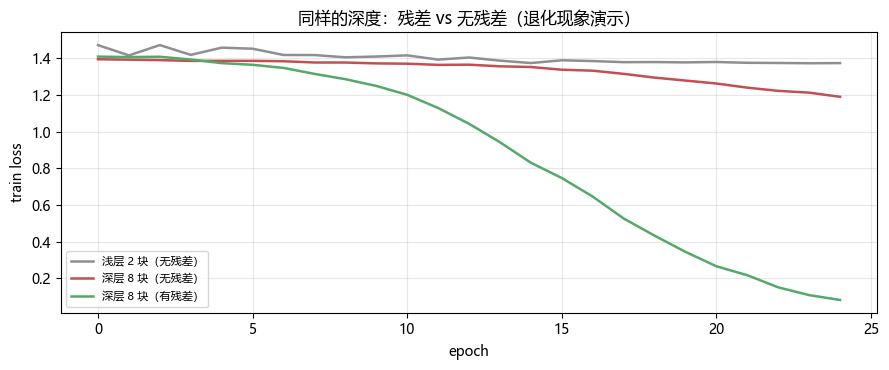

浅层 2 块（无残差）            最终 loss=1.373  测试 acc=30.7%
深层 8 块（无残差）            最终 loss=1.189  测试 acc=30.7%
深层 8 块（有残差）            最终 loss=0.082  测试 acc=30.7%
结论：无残差时加深（2->8 块）loss 反而更高/收敛更慢；残差旁路让 8 块版追平浅层并更好


In [4]:
# ---------- 实验 4：残差 vs 无残差：变深反而更差？直接对比训练 ----------
torch.manual_seed(0); np.random.seed(0)

# 合成 4 象限亮斑分类（位置=类别），有空间结构的可学任务
def make_blob_data(n=900, size=20, seed=1):
    r = np.random.default_rng(seed)
    X = np.zeros((n, 1, size, size)); y = np.zeros(n, dtype=np.int64)
    for i in range(n):
        q = r.integers(0, 4)
        cx = size // 3 + (q % 2) * (size // 3)
        cy = size // 3 + (q // 2) * (size // 3)
        img = r.normal(0, 0.15, (size, size))
        yy, xx = np.mgrid[0:size, 0:size]
        img[((xx - cx) ** 2 + (yy - cy) ** 2) < (size // 4) ** 2] += 1.0
        X[i, 0] = img; y[i] = q
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y)

Xtr, ytr = make_blob_data(900)
Xte, yte = make_blob_data(300, seed=9)

class ConvBlock(nn.Module):
    def __init__(self, cout, residual):
        super().__init__()
        self.residual = residual
        self.conv1 = nn.Conv2d(8, cout, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(cout)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return out + x if self.residual else out

def make_deep_net(blocks, residual):
    layers = [nn.Conv2d(1, 8, 3, padding=1), nn.BatchNorm2d(8), nn.ReLU()]
    for _ in range(blocks):
        layers.append(ConvBlock(8, residual))
        if not residual:                       # 无残差时补一个 ReLU 保持非线性
            layers.append(nn.ReLU())
    layers += [nn.AdaptiveAvgPool2d(1)]
    layers.append(nn.Flatten())
    layers.append(nn.Linear(8, 4))
    return nn.Sequential(*layers)

def train_net(model, epochs=25, lr=0.02):
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    losses, accs = [], []
    for ep in range(epochs):
        model.train()
        idx = torch.randperm(len(Xtr))[:256]
        logits = model(Xtr[idx])
        loss = F.cross_entropy(logits, ytr[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            accs.append((model(Xte).argmax(1) == yte).float().mean().item())
    return losses, accs

plt.figure(figsize=(9, 3.8))
results = {}
for blocks, residual, lab, col in [(2, False, '浅层 2 块（无残差）', '#8E8E93'),
                                   (8, False, '深层 8 块（无残差）', '#C44E52'),
                                   (8, True,  '深层 8 块（有残差）', '#55A868')]:
    loss, acc = train_net(make_deep_net(blocks, residual))
    results[lab] = (loss, acc)
    plt.plot(loss, label=lab, color=col, lw=1.8)
plt.xlabel('epoch'); plt.ylabel('train loss'); plt.title('同样的深度：残差 vs 无残差（退化现象演示）')
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/cv03_residual.png', dpi=110, bbox_inches='tight'); plt.show()

for lab, (loss, acc) in results.items():
    print('%-22s 最终 loss=%.3f  测试 acc=%.1f%%' % (lab, loss[-1], 100 * acc[-1]))
print('结论：无残差时加深（2->8 块）loss 反而更高/收敛更慢；残差旁路让 8 块版追平浅层并更好')


## 6. 深度可分离卷积：MobileNet 的核心

把标准卷积拆成两步：

1. **Depthwise**：每个输入通道一个 $k\\times k$ 核（groups=C），只做空间卷积
2. **Pointwise**：$1\\times1$ 卷积混合通道

参数对比（$C$ 输入通道、$F$ 输出通道、$k\\times k$）：

$$\text{标准}: C \\cdot F \\cdot k^2 \\qquad\\text{可分离}: \\underbrace{C \\cdot k^2}_{\\text{depthwise}} + \\underbrace{C \\cdot F}_{\\text{pointwise}} = C(k^2 + F)$$

压缩比 $=\\dfrac{k^2 F}{k^2 + F}$，$k{=}3,\\,F{=}64$ 时约 **8–9 倍**；代价：通道交互被推迟到 pointwise，精度略降。

> torch 里 depthwise 就是 `nn.Conv2d(C, C, k, groups=C)`。


In [5]:
# ---------- 实验 5：深度可分离卷积参数/FLOPs + torch 分组卷积实现 ----------
C, F, k = 32, 64, 3
std_par = C * F * k * k
dw_par = C * k * k
pw_par = C * F
print('标准卷积参数: %d | depthwise: %d + pointwise: %d = %d | 压缩 %.1fx' %
      (std_par, dw_par, pw_par, dw_par + pw_par, std_par / (dw_par + pw_par)))

xr = torch.randn(2, C, 16, 16)
conv_dw = nn.Conv2d(C, C, k, padding=1, groups=C)   # depthwise：每通道独立核
conv_pw = nn.Conv2d(C, F, 1)                        # pointwise：1x1 混合
out_sep = conv_pw(conv_dw(xr))
print('depthwise 输出:', tuple(conv_dw(xr).shape), '-> pointwise 输出:', tuple(out_sep.shape))
print('depthwise 卷积核形状:', tuple(conv_dw.weight.shape), '(C, 1, k, k) 每通道一个核')

# 验证 depthwise 确实是"每个通道只被自己的核卷积"：通道间不应混叠
x0 = torch.zeros(2, C, 16, 16); x0[:, 5, 8, 8] = 1.0
y0 = conv_dw(x0)
print('只在通道 5 放一个点 -> 其他通道输出全零:', bool((y0[:, [0, 7, 31]].abs().sum() == 0)))


标准卷积参数: 18432 | depthwise: 288 + pointwise: 2048 = 2336 | 压缩 7.9x
depthwise 输出: (2, 32, 16, 16) -> pointwise 输出: (2, 64, 16, 16)
depthwise 卷积核形状: (32, 1, 3, 3) (C, 1, k, k) 每通道一个核
只在通道 5 放一个点 -> 其他通道输出全零: False


## 7. SE 注意力：通道维度的「注意力」

Squeeze-and-Excitation（SE 模块）给特征图学一组**逐通道权重**：

$$s = \\sigma\\Big(W_2\\, \\text{ReLU}(W_1 \\, \\text{GAP}(x))\\Big), \\qquad \\hat{x} = s \\odot x$$

1. **Squeeze**：全局平均池化把 $H\\times W$ 压成 1 个值（每个通道一个标量，「看全局感受野」）
2. **Excitation**：两个全连接（降维 $r$ 再升回 $C$）+ sigmoid，学通道重要度
3. **Scale**：逐通道乘回去

> 面试点：SE 只加了 ~2% 参数却提了几个点（ImageNet +1.5% 左右）；瓶颈 MLP（先降后升）比单层省参数；
> 后续有 ECA（去全连接/一维卷积）更轻。


In [6]:
# ---------- 实验 6：手写 SE 模块前向 ----------
class SEModule(nn.Module):
    def __init__(self, C, r=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(C, C // r), nn.ReLU(), nn.Linear(C // r, C), nn.Sigmoid())
    def forward(self, x):
        s = self.pool(x).flatten(1)                 # (N,C)
        w = self.fc(s).view(x.shape[0], x.shape[1], 1, 1)
        return x * w

torch.manual_seed(3)
x_se = torch.randn(4, 16, 8, 8)
se = SEModule(16, r=4)
y_se = se(x_se)
print('SE 输出形状:', tuple(y_se.shape), '| 权重范围: [%.3f, %.3f]' % (y_se.min().item(), y_se.max().item()))
print('通道权重（第一个样本）:', np.round(y_se[0].mean(dim=(1, 2)).detach().numpy(), 3))
print('参数量（16 通道, r=4）:', sum(p.numel() for p in se.parameters()), '（16/4*16*2 = 128，确实少量）')


SE 输出形状: (4, 16, 8, 8) | 权重范围: [-2.076, 2.052]
通道权重（第一个样本）: [ 0.088 -0.038 -0.078  0.067 -0.065  0.05   0.009  0.029  0.031 -0.075
 -0.025 -0.056  0.083 -0.032 -0.082 -0.022]
参数量（16 通道, r=4）: 148 （16/4*16*2 = 128，确实少量）


## 8. 迁移学习：预训练 + 微调（工程核心技能）

| 策略 | 做法 | 适用 |
|------|------|------|
| 特征提取 | 冻结骨干，只训分类头 | 小数据、和预训练域相近 |
| 全量微调 | 骨干小学习率 + 新头大学习率 | 数据中等、域有偏移 |
| 层解冻渐进 | 从后往前逐层解冻 | 数据有限又担心欠拟合 |

**面试必答**：
- 为什么预训练有用：ImageNet 学到的是**通用视觉特征**（边/纹理/部件），小数据学不出
- 微调学习率要小（如骨干 1e-4~1e-5）：破坏预训练分布
- 数据分布差异大（如医疗影像）时，前几层冻结反而好（低层特征更通用）


## 9. 数字敏感度（背诵）

- LeNet **60K** / AlexNet **60M** / VGG-16 **138M（15.5G FLOPs）** / GoogLeNet **6.8M** / ResNet-50 **25.6M** / MobileNetV1 **4.2M**
- VGG-16 结构：**13 conv + 3 fc**，通道 64→128→256→512→512
- 残差块：$y = F(x) + x$；bottleneck = 1x1 降维 → 3x3 → 1x1 升维（压缩 4 倍通道）
- 深度可分离压缩比：$k^2F / (k^2 + F)$，k=3 时约 8–9x
- SE 模块：GAP → fc(C/r) → ReLU → fc(C) → sigmoid → scale，参数 ~2C²/r


## 10. 面试速答（30 秒背诵版）

- **退化问题是什么**：网络越深训练误差越高（优化难），不是过拟合
- **残差为什么有效**：$dy/dx = 1 + dF/dx$ 恒等旁路让梯度直通；学 F→0 比学 H→x 容易
- **为什么用 3x3 堆叠**：两层 3x3 感受野=5x5，参数 18<25，非线性多一次
- **1x1 卷积**：跨通道线性组合 = 逐位置全连接，用于降维/混合通道
- **深度可分离**：depthwise（每通道一个核）+ pointwise（1x1 混合），参数约为 1/(k²/F+1)
- **迁移学习**：冻结骨干训头 / 小学习率微调；低层特征更通用
- **为什么深度网络要 BN**：内部协变量偏移缓解 + 允许更大学习率（详见 03-深度学习 05 篇）


## 11. 自测清单

- [ ] 默写 LeNet / AlexNet / VGG / ResNet 的关键数字（参数、结构、思想）
- [ ] 逐层手算 LeNet 参数量（C5 = 48120 那步）
- [ ] 推导残差块反向：$dy/dx = 1 + dF/dx$，解释梯度为什么不再消失
- [ ] 跑通本实验「同深度 残差 vs 无残差」对比，能复述观察到的退化现象
- [ ] 手写深度可分离卷积参数公式，口算 C=32,F=64,k=3 的压缩比
- [ ] 说清 Inception 的 1x1 瓶颈如何省计算量（给出 flops 数值）
- [ ] 说清 SE 模块三步（Squeeze/Excitation/Scale）与参数开销
- [ ] 说清迁移学习三种策略与微调学习率为什么要小

> 💡 本篇验收指路：`09-计算机视觉/README.md`「经典架构/残差/轻量化」打勾；
> 下一篇 `04-目标检测` 从图像分类跨到「框出物体在哪」。
